# Raport z zadań z listy 2

## załadowanie zbiorów danych
Do wykonania zadań klasyfikacyjnych na ocenę 3.0 oraz na ocenę 3.5 używam zbioru Telco Customer Churn (Target Churn). Do zadań regresyjnych na ocenę 4.0, 4.5 oraz 5.0 używam zbioru Diamonds (target Price)

In [35]:
from file_operations import load_diamonds_data, load_telco_data, split_diamonds_data, split_telco_data
import pandas as pd

telco_df = load_telco_data()
telco_train_df, telco_test_df = split_telco_data(telco_df)

diamonds_df = load_diamonds_data()
diamonds_train_df, diamonds_test_df = split_diamonds_data(diamonds_df)

## Zadanie 3.0

W tej czesci buduje model klasyfikacyjny oparty o drzewo decyzyjne dla zbioru `Telco Customer Churn`. Najpierw przygotowuje dane, potem ucze model, a na koncu oceniam go metrykami odpowiednimi dla niezbalansowanej klasyfikacji.


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

from plots import plot_classification_metrics
from preprocessing import prepare_telco_classification_data


# Prosta klasa zgodna ze stylem fit(X, y) i predict(X).
class TreeDecision:
    def __init__(self, max_depth=5, random_state=42):
        self.model = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
        self.columns = None

    def fit(self, X, y):
        # Kodujemy zmienne kategorialne do postaci 0/1.
        X_encoded = pd.get_dummies(X)
        self.columns = X_encoded.columns.tolist()
        self.model.fit(X_encoded, y)
        return self

    def predict(self, X):
        # W tescie ustawiamy te same kolumny co na treningu.
        X_encoded = pd.get_dummies(X)
        X_encoded = X_encoded.reindex(columns=self.columns, fill_value=0)
        return self.model.predict(X_encoded)


X_train, y_train, X_test, y_test = prepare_telco_classification_data(
    telco_train_df,
    telco_test_df,
)

model = TreeDecision(max_depth=5)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


,metric,value
0,accuracy,0.7984
1,precision,0.6347
2,recall,0.5668
3,f1,0.5989


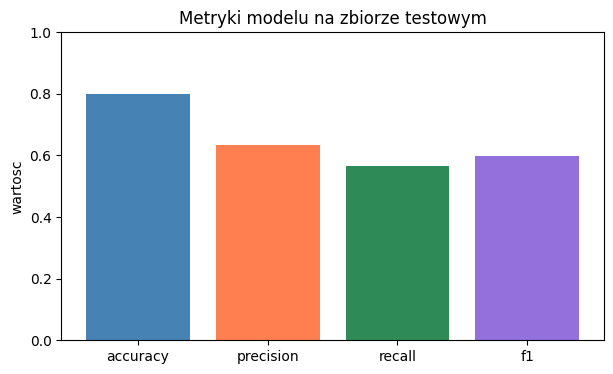

In [ ]:

metrics_df = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1"],
        "value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, pos_label="Yes"),
            recall_score(y_test, y_pred, pos_label="Yes"),
            f1_score(y_test, y_pred, pos_label="Yes"),
        ],
    }
)

display(metrics_df.round(4))

plot_classification_metrics(metrics_df)



**Opis tabeli metryk i wykresu metryk**

Model drzewa decyzyjnego osiągnął na zbiorze testowym accuracy równe około 0.80, co oznacza, że poprawnie sklasyfikował około 80% obserwacji. Sama trafność nie jest jednak wystarczającą miarą jakości modelu, ponieważ zbiór Telco Customer Churn jest niezbalansowany — większość klientów należy do klasy No, czyli nie rezygnuje z usług.

Dla klasy Yes, czyli klientów rezygnujących z usług, model osiągnął precision około 0.63. Oznacza to, że spośród klientów wskazanych przez model jako odchodzących około 63% rzeczywiście odeszło.

Recall wynosi około 0.57, co oznacza, że model wykrywa około 57% wszystkich rzeczywistych przypadków odejścia. Pozostała część klientów odchodzących zostaje błędnie zaklasyfikowana jako klienci pozostający.

Wartość F1-score wynosząca około 0.60 pokazuje kompromis między precision i recall. Model działa przyzwoicie ogólnie, ale ma ograniczoną skuteczność w wykrywaniu klasy mniejszościowej Yes, która w tym problemie biznesowo jest najważniejsza.


Macierz pomylek:
[[913 122]
 [162 212]]


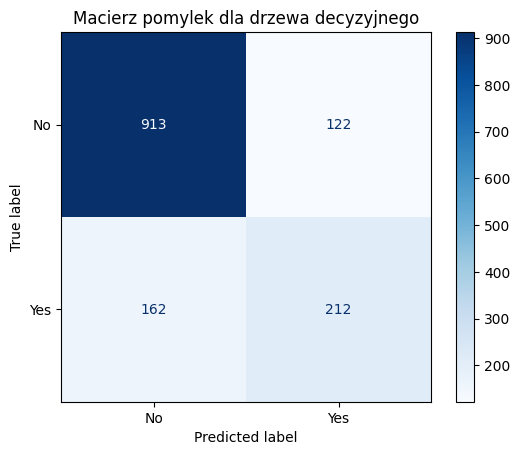

In [ ]:
from plots import plot_confusion_matrix


print("Macierz pomylek:")
print(confusion_matrix(y_test, y_pred, labels=["No", "Yes"]))

plot_confusion_matrix(y_test, y_pred)


**Opis macierzy pomylek**

Macierz pomyłek pokazuje szczegółowy rozkład poprawnych i błędnych klasyfikacji. Model poprawnie przewidział 913 przypadków klasy No, czyli klientów, którzy nie zrezygnowali z usług, oraz 212 przypadków klasy Yes, czyli klientów, którzy rzeczywiście odeszli.

Błędy modelu wystąpiły w dwóch sytuacjach. W 122 przypadkach model przewidział odejście klienta, chociaż klient faktycznie pozostał. Są to fałszywe alarmy. W 162 przypadkach klient rzeczywiście odszedł, ale model przewidział, że pozostanie. Ta druga grupa błędów jest szczególnie istotna, ponieważ obniża recall dla klasy Yes.

Macierz potwierdza, że model lepiej rozpoznaje klasę No niż klasę Yes. Wynika to częściowo z niezbalansowania danych, ale również z tego, że przypadki rezygnacji są trudniejsze do jednoznacznego odróżnienia.


## Zadanie 3.5

W tej czesci przechodze od samej skutecznosci modelu do jego interpretacji. Pokazuje reguly drzewa, waznosc cech oraz reczne obliczenia entropii i information gain, aby sprawdzic, czy decyzje modelu maja sens.


Reguly drzewa decyzyjnego:
|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |--- Contract_One year <= 0.50
|   |   |   |   |--- OnlineBackup_No <= 0.50
|   |   |   |   |   |--- class: No
|   |   |   |   |--- OnlineBackup_No >  0.50
|   |   |   |   |   |--- class: No
|   |   |   |--- Contract_One year >  0.50
|   |   |   |   |--- MonthlyCharges <= 72.17
|   |   |   |   |   |--- class: No
|   |   |   |   |--- MonthlyCharges >  72.17
|   |   |   |   |   |--- class: No
|   |   |--- OnlineSecurity_No >  0.50
|   |   |   |--- Contract_Two year <= 0.50
|   |   |   |   |--- PaymentMethod_Mailed check <= 0.50
|   |   |   |   |   |--- class: No
|   |   |   |   |--- PaymentMethod_Mailed check >  0.50
|   |   |   |   |   |--- class: No
|   |   |   |--- Contract_Two year >  0.50
|   |   |   |   |--- MonthlyCharges <= 54.47
|   |   |   |   |   |--- class: No
|   |   |   |   |--- MonthlyCharges >  54.47
|   |   |   |   |   |--- c

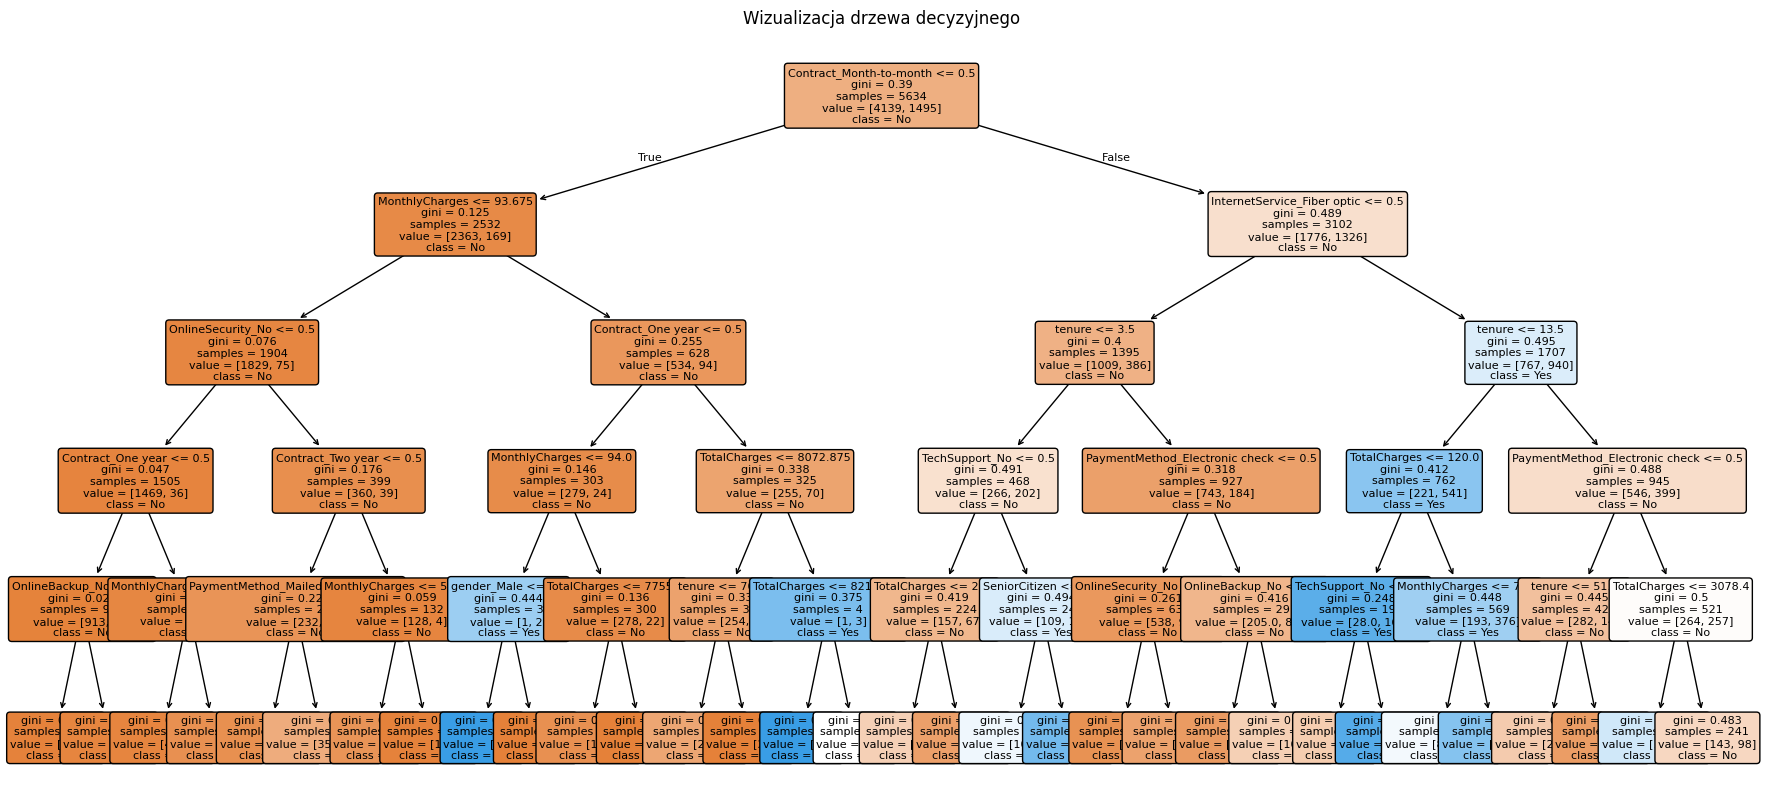

In [ ]:
import pandas as pd
from math import log2
from sklearn.tree import export_text

from helpers import get_thresholds_from_tree
from plots import plot_decision_tree
from preprocessing import prepare_telco_classification_data


X_train, y_train, X_test, y_test = prepare_telco_classification_data(
    telco_train_df,
    telco_test_df,
)


interpretation_model = TreeDecision(max_depth=5)
interpretation_model.fit(X_train, y_train)

print("Reguly drzewa decyzyjnego:")
print(export_text(interpretation_model.model, feature_names=interpretation_model.columns))


plot_decision_tree(interpretation_model.model, interpretation_model.columns)

# Kodujemy trening dokladnie tak jak widzi go model.
encoded_train_df = pd.get_dummies(X_train)
encoded_train_df = encoded_train_df.reindex(columns=interpretation_model.columns, fill_value=0)


**Opis wizualizacji drzewa i regu? decyzyjnych**

Wizualizacja drzewa decyzyjnego pokazuje, na podstawie jakich warunków model klasyfikuje klientów jako pozostających lub odchodzących. Cechy znajdujące się blisko korzenia drzewa mają największe znaczenie, ponieważ są używane do pierwszych podziałów dużych grup obserwacji.

Najważniejszym warunkiem jest Contract_Month-to-month. Oznacza to, że typ umowy silnie wpływa na ryzyko rezygnacji. Klienci z umową miesięczną są mniej związani z operatorem, dlatego częściej mogą rezygnować z usług. Kolejne istotne cechy to m.in. InternetService_Fiber optic, tenure, MonthlyCharges, TechSupport_No oraz OnlineSecurity_No. Jest to zgodne z intuicją biznesową: krótki staż klienta, wysokie opłaty miesięczne oraz brak usług dodatkowych mogą zwiększać ryzyko odejścia.

Dla max_depth = 5 drzewo jest bardziej rozbudowane niż prosty system reguł, dlatego może uchwycić więcej zależności między cechami. Jednocześnie ograniczenie głębokości zmniejsza ryzyko przeuczenia i poprawia czytelność modelu.

W porównaniu z prostym systemem reguł drzewo osiąga wyższą trafność, ponieważ automatycznie wybiera cechy i progi podziału na podstawie danych treningowych(zadnaniach z listy pierwszej acccuracy wówczas wynioslo okolo 73% a tutaj 80%)


Cechy z dodatnia waznoscia, czyli realnie wykorzystane przez drzewo:


,feature,importance
0,Contract_Month-to-month,0.513973
1,InternetService_Fiber optic,0.163262
2,tenure,0.156717
3,TotalCharges,0.036499
4,MonthlyCharges,0.035922
5,PaymentMethod_Electronic check,0.027931
6,TechSupport_No,0.026824
7,Contract_One year,0.009218
8,OnlineBackup_No,0.009198
9,OnlineSecurity_No,0.008620


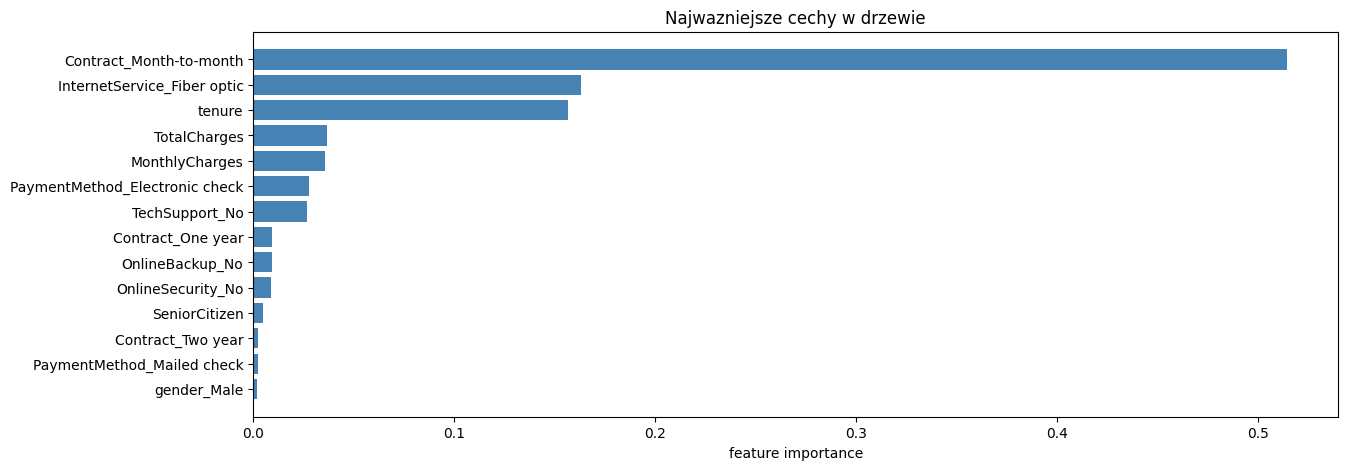

In [ ]:
from plots import plot_feature_importance


# Pelna tabela wszystkich cech po kodowaniu.
all_importance_df = pd.DataFrame(
    {
        "feature": interpretation_model.columns,
        "importance": interpretation_model.model.feature_importances_,
    }
)
all_importance_df = all_importance_df.sort_values("importance", ascending=False).reset_index(drop=True)


used_importance_df = all_importance_df[all_importance_df["importance"] > 0].copy()
used_importance_df = used_importance_df.reset_index(drop=True)

print("Cechy z dodatnia waznoscia, czyli realnie wykorzystane przez drzewo:")
display(used_importance_df.round(6))

top_features_df = used_importance_df.head(14).copy()
plot_feature_importance(top_features_df)


**Opis tabeli i wykresu waznosci cech**

Wykres ważności cech pokazuje, które zmienne miały największy wpływ na decyzje drzewa. Najważniejszą cechą jest Contract_Month-to-month, co oznacza, że typ umowy był kluczowym kryterium podziału klientów. Duże znaczenie mają również InternetService_Fiber optic, tenure, TotalCharges oraz MonthlyCharges.

Wyniki są zgodne z interpretacją biznesową. Największe ryzyko rezygnacji dotyczy klientów z umową miesięczną, krótszym stażem korzystania z usług oraz wyższymi opłatami. Wysoka ważność cech związanych z usługą internetową i kosztami sugeruje, że decyzja o odejściu klienta jest silnie powiązana zarówno z typem oferty, jak i z poziomem miesięcznych obciążeń.

Warto zauważyć, że drzewo nie wykorzystuje wszystkich cech równomiernie. Kilka pierwszych zmiennych ma zdecydowanie większą ważność niż pozostałe, co oznacza, że model opiera decyzje głównie na wąskiej grupie najsilniejszych predyktorów.

Warto zaznaczyć, że ważność cech w drzewie nie oznacza bezpośrednio kierunku wpływu zmiennej, lecz pokazuje, jak bardzo dana cecha zmniejsza niejednorodność klas w kolejnych podziałach.


,feature,tree_threshold,feature_importance,manual_information_gain
0,Contract_Month-to-month,0.5,0.513973,0.133580
1,gender_Male,0.5,0.001889,0.000004


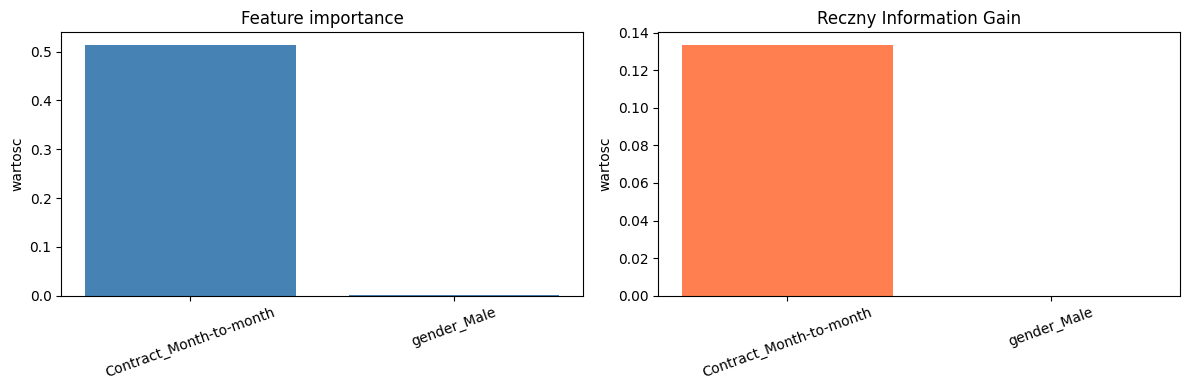

In [ ]:
from plots import plot_information_gain_comparison


feature_thresholds = get_thresholds_from_tree(interpretation_model.model, interpretation_model.columns)

most_important_feature = used_importance_df.iloc[0]["feature"]
least_important_feature = used_importance_df.iloc[-1]["feature"]

most_important_threshold = feature_thresholds[most_important_feature][0]
least_important_threshold = feature_thresholds[least_important_feature][0]

# Reczne liczenie entropii zostaje w raporcie, bo jest wprost wymagane w poleceniu.
def entropy_manual(y):
    probabilities = y.value_counts(normalize=True)
    entropy_value = 0
    for probability in probabilities:
        if probability > 0:
            entropy_value += -probability * log2(probability)
    return entropy_value


# Reczne liczenie information gain dla pojedynczego podzial gain = parent_entropy - mean(children_entropy)
def information_gain_manual(X, y, feature_name, threshold):
    # liczymy entropie na poczatku
    parent_entropy = entropy_manual(y)

    #dzielimy zbiór na dwie grupy
    left_mask = X[feature_name] <= threshold
    right_mask = X[feature_name] > threshold
    y_left = y[left_mask]
    y_right = y[right_mask]

    if len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    #obliczamy wagi grup
    left_weight = len(y_left) / len(y)
    right_weight = len(y_right) / len(y)

    #entropia dziecka
    children_entropy = (
        left_weight * entropy_manual(y_left)
        + right_weight * entropy_manual(y_right)
    )

    return parent_entropy - children_entropy


most_important_gain = information_gain_manual(
    encoded_train_df,
    y_train,
    most_important_feature,
    most_important_threshold,
)

least_important_gain = information_gain_manual(
    encoded_train_df,
    y_train,
    least_important_feature,
    least_important_threshold,
)

comparison_df = pd.DataFrame(
    {
        "feature": [most_important_feature, least_important_feature],
        "tree_threshold": [most_important_threshold, least_important_threshold],
        "feature_importance": [
            used_importance_df.iloc[0]["importance"],
            used_importance_df.iloc[-1]["importance"],
        ],
        "manual_information_gain": [most_important_gain, least_important_gain],
    }
)

display(comparison_df.round(6))


comparison_plot_df = comparison_df.copy()
comparison_plot_df["feature_importance"] = comparison_plot_df["feature_importance"].astype(float)
comparison_plot_df["manual_information_gain"] = comparison_plot_df["manual_information_gain"].astype(float)
plot_information_gain_comparison(comparison_plot_df)


**Opis porownania feature importance i information gain**

Porównanie feature_importance oraz ręcznie obliczonego information gain pokazuje zgodny kierunek interpretacji. Cecha Contract_Month-to-month ma bardzo wysoką ważność w modelu oraz wysoki zysk informacyjny, co oznacza, że podział według typu umowy istotnie zmniejsza niepewność dotyczącą klasy Churn.

Dla cechy gender_Male zarówno ważność w modelu, jak i ręcznie obliczony zysk informacyjny są bliskie zeru. Oznacza to, że płeć klienta praktycznie nie dostarcza użytecznej informacji do przewidywania rezygnacji.

Należy jednak pamiętać, że feature_importance w drzewie decyzyjnym jest liczona na podstawie wszystkich podziałów, w których dana cecha została użyta, natomiast ręcznie liczony information gain dotyczy konkretnego pojedynczego podziału. Mimo tej różnicy obie miary prowadzą do tego samego wniosku: typ umowy jest bardzo ważną cechą, a płeć ma marginalne znaczenie.

In [42]:
# Krotkie podsumowanie liczbowe dla raportu.
print("Entropia calego zbioru treningowego:", round(entropy_manual(y_train), 6))
print("Najwazniejsza cecha:", most_important_feature)
print("Prog podzialu:", round(most_important_threshold, 6))
print("Information Gain:", round(most_important_gain, 6))
print()
print("Cecha o najmniejszej dodatniej waznosci:", least_important_feature)
print("Prog podzialu:", round(least_important_threshold, 6))
print("Information Gain:", round(least_important_gain, 6))


Entropia calego zbioru treningowego: 0.834717
Najwazniejsza cecha: Contract_Month-to-month
Prog podzialu: 0.5
Information Gain: 0.13358

Cecha o najmniejszej dodatniej waznosci: gender_Male
Prog podzialu: 0.5
Information Gain: 4e-06


**Opis recznych obliczen entropii i information gain**

Ręczne obliczenia entropii oraz zysku informacyjnego potwierdzają wyniki uzyskane przez model drzewa decyzyjnego. Entropia całego zbioru treningowego wynosi około 0.835, co oznacza, że w danych występuje zauważalna niepewność co do klasy Churn.

Dla cechy Contract_Month-to-month zysk informacyjny wynosi około 0.134, czyli podział według typu umowy wyraźnie zmniejsza niepewność klasyfikacji. Oznacza to, że informacja o rodzaju umowy jest silnie powiązana z ryzykiem odejścia klienta.

Dla cechy gender_Male zysk informacyjny wynosi około 0.000004, czyli praktycznie zero. Taki wynik oznacza, że podział według płci prawie nie zmienia struktury klas i nie pomaga w przewidywaniu rezygnacji klienta.


## Zadanie 4.0

W tej czesci porownuje trzy sposoby uczenia regresji liniowej na zbiorze `Diamonds`: rozwiazanie analityczne, gradient descent oraz model biblioteczny z `scikit-learn`. Wszystkie modele ucza sie na tych samych danych, dzieki czemu mozna uczciwie porownac ich bledy i wagi.


,model,mse,mae
0,normal equation,1.288705e+06,737.1514
1,gradient descent,1.288705e+06,737.1514
2,sklearn LinearRegression,1.288705e+06,737.1514


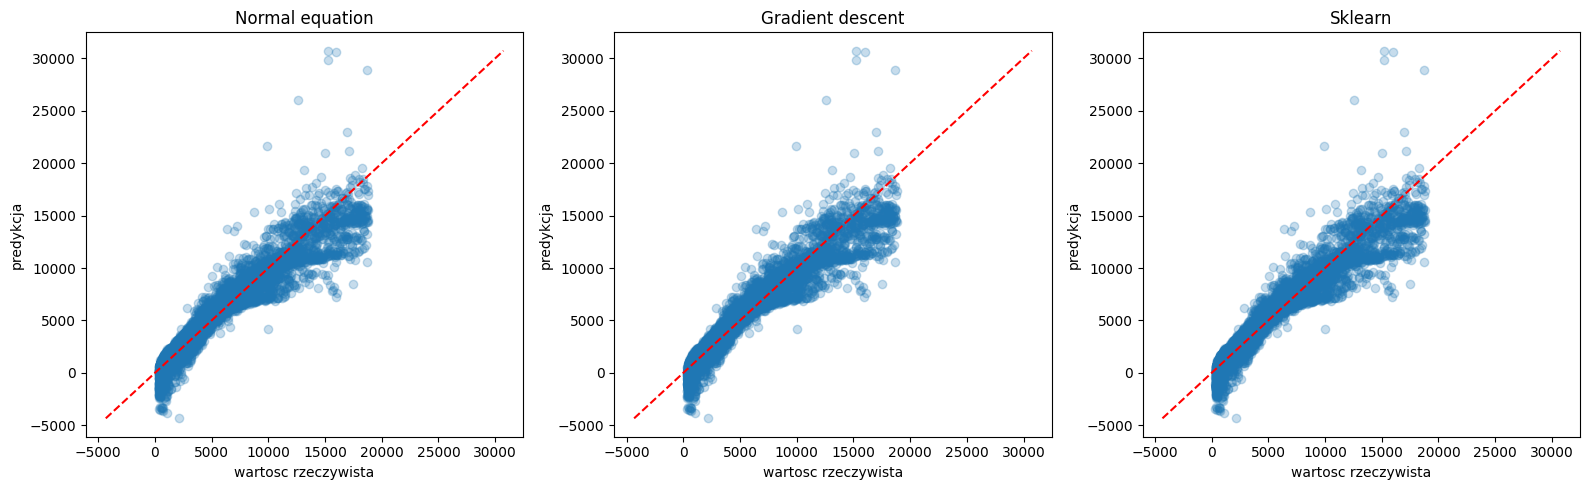

In [ ]:
import importlib
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from helpers import add_intercept, standardize_train_test
from plots import plot_loss_history, plot_regression_predictions
import preprocessing
importlib.reload(preprocessing)
from preprocessing import prepare_diamonds_regression_data


class LinearRegressionNormalEquation:
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        # Dodajemy kolumnę jedynek. Bez tego linia regresji musiałaby przechodzić przez środek układu współrzędnych (0,0)
        X_with_intercept = add_intercept(X)
        
        # Obliczamy wagi korzystając z macierzy pseudoodwrotnej Moore'a-Penrose'a.
        self.weights = np.linalg.pinv(X_with_intercept) @ y
        return self

    def predict(self, X):
        # Aby przewidzieć wynik również musimy dodać kolumnę jedynek.
        X_with_intercept = add_intercept(X)
        # Wynik to iloczyn macierzowy cech i wyliczonych wag.
        return X_with_intercept @ self.weights
    
    
class LinearRegressionGradientDescent:
    def __init__(self, learning_rate=0.1, epochs=5000):
        self.learning_rate = learning_rate  # długośc kroku schodzenia
        self.epochs = epochs  # Liczba kroków
        self.weights = None 
        self.loss_history = []  # Historia błędu MSE, aby sprawdzić czy model się zbiega

    def fit(self, X, y):
        # Przygotowanie danych i zainicjowanie wag zerami.
        X_with_intercept = add_intercept(X)
        self.weights = np.zeros(X_with_intercept.shape[1])

        for _ in range(self.epochs):
            # Obliczamy aktualne przewidywania modelu
            y_pred = X_with_intercept @ self.weights
            
            # Obliczamy błąd
            error = y_pred - y
            
            # Obliczamy gradient gdzie (2/n) * X^T * error to pochodna funkcji MSE.
            gradient = (2 / len(X_with_intercept)) * (X_with_intercept.T @ error)
            
            # Aktualizacja wag0 robimy mały krok w kierunku przeciwnym do gradientu.
            self.weights = self.weights - self.learning_rate * gradient
            
            # Zapisujemy aktualny błąd średniokwadratowy do historii.
            mse_value = np.mean(error ** 2)
            self.loss_history.append(mse_value)

        return self

    def predict(self, X):
        # Przewidywanie polega na przemnożeniu danych wejściowych przez wyuczone wagi.
        X_with_intercept = add_intercept(X)
        return X_with_intercept @ self.weights



X_train_raw, y_train, X_test_raw, y_test = prepare_diamonds_regression_data(
    diamonds_train_df,
    diamonds_test_df,
)

X_train_encoded = pd.get_dummies(X_train_raw)
X_test_encoded = pd.get_dummies(X_test_raw)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Wszystkie trzy modele ucza sie na tej samej, recznie standaryzowanej macierzy.
X_train_array = X_train_encoded.to_numpy(dtype=float)
X_test_array = X_test_encoded.to_numpy(dtype=float)
# przeskalowanie 
X_train_scaled, X_test_scaled = standardize_train_test(X_train_array, X_test_array)
y_train_array = y_train.to_numpy(dtype=float)
y_test_array = y_test.to_numpy(dtype=float)

normal_model = LinearRegressionNormalEquation()
gradient_model = LinearRegressionGradientDescent(learning_rate=0.1, epochs=5000)
sklearn_model = LinearRegression()

normal_model.fit(X_train_scaled, y_train_array)
gradient_model.fit(X_train_scaled, y_train_array)
sklearn_model.fit(X_train_scaled, y_train_array)


learning_rate_histories = {}
for learning_rate in [0.001, 0.01, 0.1]:
    lr_model = LinearRegressionGradientDescent(learning_rate=learning_rate, epochs=5000)
    lr_model.fit(X_train_scaled, y_train_array)
    learning_rate_histories[str(learning_rate)] = lr_model.loss_history

normal_predictions = normal_model.predict(X_test_scaled)
gradient_predictions = gradient_model.predict(X_test_scaled)
sklearn_predictions = sklearn_model.predict(X_test_scaled)

results_df = pd.DataFrame(
    {
        "model": ["normal equation", "gradient descent", "sklearn LinearRegression"],
        "mse": [
            mean_squared_error(y_test_array, normal_predictions),
            mean_squared_error(y_test_array, gradient_predictions),
            mean_squared_error(y_test_array, sklearn_predictions),
        ],
        "mae": [
            mean_absolute_error(y_test_array, normal_predictions),
            mean_absolute_error(y_test_array, gradient_predictions),
            mean_absolute_error(y_test_array, sklearn_predictions),
        ],
    }
)

display(results_df.round(4))


predictions_list = [
    ("Normal equation", normal_predictions),
    ("Gradient descent", gradient_predictions),
    ("Sklearn", sklearn_predictions),
]
plot_regression_predictions(y_test_array, predictions_list)


**Opis tabeli metryk regresji i wykresu wartosc rzeczywista vs predykcja**

Tabela porównuje jakość trzech implementacji regresji liniowej: rozwiązania analitycznego, gradient descent oraz modelu LinearRegression z biblioteki scikit-learn. Wyniki dla rozwiązania analitycznego i sklearn LinearRegression są identyczne, co potwierdza poprawność implementacji metody opartej na równaniu normalnym. Gradient descent uzyskał bardzo zbliżone, lecz nieco gorsze wyniki, co może wynikać z ograniczonej liczby iteracji, dobranego learning rate albo warunku zatrzymania algorytmu.

Na wykresach porównano wartości rzeczywiste z predykcjami. Czerwona linia przerywana oznacza idealne przewidywania, czyli sytuację, w której predykcja jest równa wartości rzeczywistej. Im bliżej tej linii znajdują się punkty, tym lepsze są przewidywania modelu. Wszystkie trzy wykresy mają bardzo podobny kształt, co oznacza, że modele uczą się tej samej zależności. Widoczne rozproszenie punktów pokazuje jednak, że regresja liniowa nie opisuje idealnie wszystkich obserwacji, szczególnie dla wyższych cen.



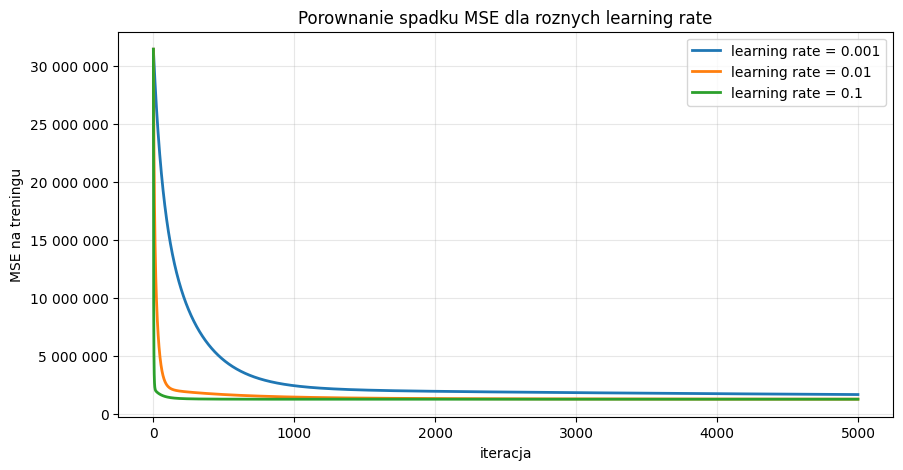

In [44]:
plot_loss_history(learning_rate_histories)


**Opis wykresu porownania learning rate dla gradient descent**

Wykres przedstawia zmianę wartości funkcji kosztu, mierzonej jako MSE, w kolejnych iteracjach algorytmu gradient descent. Na początku błąd jest bardzo wysoki, ponieważ parametry modelu są jeszcze dalekie od optimum. W pierwszych iteracjach MSE gwałtownie spada, co oznacza, że algorytm szybko poprawia wartości współczynników model

W dalszej części krzywa się wypłaszcza, ponieważ model zbliża się do minimum funkcji kosztu. Brak gwałtownych skoków i brak wzrostu błędu wskazują, że dobrany learning rate jest stabilny. Ostatecznie algorytm zbiega do rozwiązania bliskiego optimum, choć wynik gradient descent jest minimalnie gorszy niż rozwiązanie analityczne

Wykres pokazuje także jak rozne wartosci learning rate wplywaja na tempo i stabilnosc uczenia modelu. Mala wartosc, na przyklad 0.001, daje bardzo powolny spadek bledu. Srednia wartosc 0.01 prowadzi do stabilnej, ale wolniejszej zbieznosci. W glownym modelu zostawiono 0.1, bo dla tego zadania daje ono szybsze dojscie do rozwiazania bardzo bliskiego scikit-learn.


In [ ]:
# Wypisujemy wektory wag dla wszystkich trzech podejsc.
feature_names = ["intercept"] + X_train_encoded.columns.tolist()
weights_df = pd.DataFrame(
    {
        "feature": feature_names,
        "normal_equation": normal_model.weights,
        "gradient_descent": gradient_model.weights,
        "sklearn": np.concatenate([[sklearn_model.intercept_], sklearn_model.coef_]),
    }
)

display(weights_df.round(6))


weight_comparison_df = pd.DataFrame(
    {
        "comparison": ["normal vs sklearn", "gradient vs sklearn"],
        "max_abs_difference": [
            np.max(np.abs(normal_model.weights[1:] - sklearn_model.coef_)),
            np.max(np.abs(gradient_model.weights[1:] - sklearn_model.coef_)),
        ],
        "intercept_difference": [
            abs(normal_model.weights[0] - sklearn_model.intercept_),
            abs(gradient_model.weights[0] - sklearn_model.intercept_),
        ],
    }
)

display(weight_comparison_df.round(10))


,feature,normal_equation,gradient_descent,sklearn
0,intercept,3939.490707,3939.490707,3939.490707
1,carat,5339.601689,5339.601148,5339.601689
2,depth,-92.964717,-92.964640,-92.964717
3,table,-59.299400,-59.299400,-59.299400
4,x,-1129.191378,-1129.190172,-1129.191378
5,y,-4.048849,-4.049135,-4.048849
6,z,-25.818033,-25.818424,-25.818033
7,cut_Fair,-126.445756,-126.445762,-126.445756
8,cut_Good,-44.432402,-44.432402,-44.432402
9,cut_Ideal,54.910804,54.910805,54.910804


,comparison,max_abs_difference,intercept_difference
0,normal vs sklearn,0.000000,0.0
1,gradient vs sklearn,0.001207,0.0


**Opis tabeli wag i tabeli roznic wzgledem scikit-learn**

Wektor wag dla rozwiazania analitycznego i dla modelu scikit-learn jest praktycznie identyczny. Wagi gradient descent sa rowniez bardzo bliskie, a tabela roznic pokazuje, ze maksymalne odchylenia sa bardzo male. Oznacza to, ze implementacja metody iteracyjnej dziala poprawnie i prowadzi do tego samego minimum bledu co rozwiazanie macierzowe.



## Zadanie 4.5


W tej czesci interpretuje wspolczynniki regresji liniowej. Najpierw analizuje wagi modelu po skalowaniu, bo wtedy ich wartosci sa porownywalne, a potem zestawiam je z wagami modelu bez skalowania, zeby pokazac, jak skala cech wplywa na interpretacje.


Najwieksze wagi po skalowaniu:


,feature,weight_after_scaling,abs_weight_after_scaling
0,carat,5339.6017,5339.6017
1,x,-1129.1914,1129.1914
2,clarity_SI2,-493.5775,493.5775
3,clarity_I1,-464.5967,464.5967
4,color_J,-384.5201,384.5201
5,clarity_VVS2,274.1355,274.1355
6,color_I,-251.6193,251.6193
7,clarity_VVS1,251.5577,251.5577
8,clarity_IF,241.3586,241.3586
9,color_D,211.0741,211.0741


Najwieksze wagi bez skalowania:


,feature,weight_without_scaling,abs_weight_without_scaling
0,carat,11280.7843,11280.7843
1,clarity_I1,-3322.1929,3322.1929
2,clarity_IF,2043.7517,2043.7517
3,clarity_VVS1,1693.1000,1693.1000
4,clarity_VVS2,1636.0185,1636.0185
5,color_D,1403.7812,1403.7812
6,clarity_VS1,1257.7126,1257.7126
7,color_E,1185.5826,1185.5826
8,color_F,1124.0648,1124.0648
9,cut_Ideal,1058.7735,1058.7735


Porownanie tych samych cech po skalowaniu i bez skalowania:


,feature,weight_after_scaling,abs_weight_after_scaling,weight_without_scaling,abs_weight_without_scaling
0,carat,5339.6017,5339.6017,11280.7843,11280.7843
1,x,-1129.1914,1129.1914,-1008.0416,1008.0416
2,clarity_SI2,-493.5775,493.5775,-620.7530,620.7530
3,clarity_I1,-464.5967,464.5967,-3322.1929,3322.1929
4,color_J,-384.5201,384.5201,-968.2386,968.2386
5,clarity_VVS2,274.1355,274.1355,1636.0185,1636.0185
6,color_I,-251.6193,251.6193,-75.8033,75.8033
7,clarity_VVS1,251.5577,251.5577,1693.1000,1693.1000
8,clarity_IF,241.3586,241.3586,2043.7517,2043.7517
9,color_D,211.0741,211.0741,1403.7812,1403.7812


Waga cechy carat bez skalowania: 11280.7843


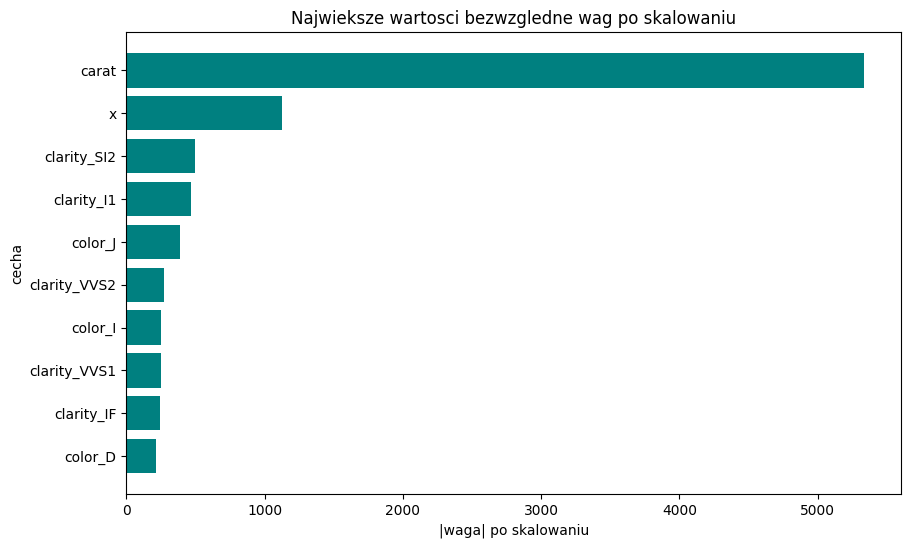

In [ ]:
import pandas as pd

from helpers import build_weight_table
from plots import plot_top_weights


scaled_weight_table = build_weight_table(
    X_train_encoded.columns.tolist(),
    normal_model.weights[1:],
    "weight_after_scaling",
)

print("Najwieksze wagi po skalowaniu:")
display(scaled_weight_table.head(10).round(4))

normal_model_without_scaling = LinearRegressionNormalEquation()
normal_model_without_scaling.fit(X_train_array, y_train_array)

raw_weight_table = build_weight_table(
    X_train_encoded.columns.tolist(),
    normal_model_without_scaling.weights[1:],
    "weight_without_scaling",
)

print("Najwieksze wagi bez skalowania:")
display(raw_weight_table.head(10).round(4))


weight_comparison_45_df = scaled_weight_table[
    ["feature", "weight_after_scaling", "abs_weight_after_scaling"]
].merge(
    raw_weight_table[["feature", "weight_without_scaling", "abs_weight_without_scaling"]],
    on="feature",
    how="left",
)

print("Porownanie tych samych cech po skalowaniu i bez skalowania:")
display(weight_comparison_45_df.head(10).round(4))

carat_weight_without_scaling = raw_weight_table.loc[
    raw_weight_table["feature"] == "carat",
    "weight_without_scaling",
].iloc[0]
print("Waga cechy carat bez skalowania:", round(carat_weight_without_scaling, 4))


plot_top_weights(
    weight_comparison_45_df,
    "abs_weight_after_scaling",
    "Najwieksze wartosci bezwzgledne wag po skalowaniu",
    "|waga| po skalowaniu",
)


**Opis tabel wag po skalowaniu i bez skalowania oraz wykresu top wag**

Wykres przedstawia największe wartości bezwzględne współczynników regresji po skalowaniu zmiennych. Dzięki standaryzacji cechy są sprowadzone do wspólnej skali, dlatego można porównywać względną siłę ich wpływu na predykcję. Największy wpływ na przewidywaną cenę ma cecha carat, co jest zgodne z intuicją, ponieważ masa diamentu jest jednym z głównych czynników determinujących jego cenę.

Kolejne istotne cechy to między innymi x oraz wybrane kategorie jakościowe, takie jak clarity i color. Ich obecność wśród największych wag oznacza, że oprócz masy znaczenie mają również wymiary i parametry jakościowe diamentu. Należy jednak pamiętać, że wykres pokazuje wartości bezwzględne wag, więc informuje o sile wpływu cechy, ale nie pokazuje kierunku tego wpływu. Aby określić, czy dana cecha zwiększa czy zmniejsza przewidywaną cenę, należałoby spojrzeć na znak współczynnika.

W modelu bez skalowania mozna tez podac interpretacje pojedynczej wagi wprost po ludzku. Dla cechy `carat` wspolczynnik wynosi okolo `11280.78`, co oznacza, ze przy pozostalych cechach stalych wzrost masy diamentu o `1` karat zwieksza przewidywana cene srednio o okolo `11281` jednostek ceny. Taka interpretacja jest mozliwa dlatego, ze `carat` wystepuje tu w swojej naturalnej jednostce.


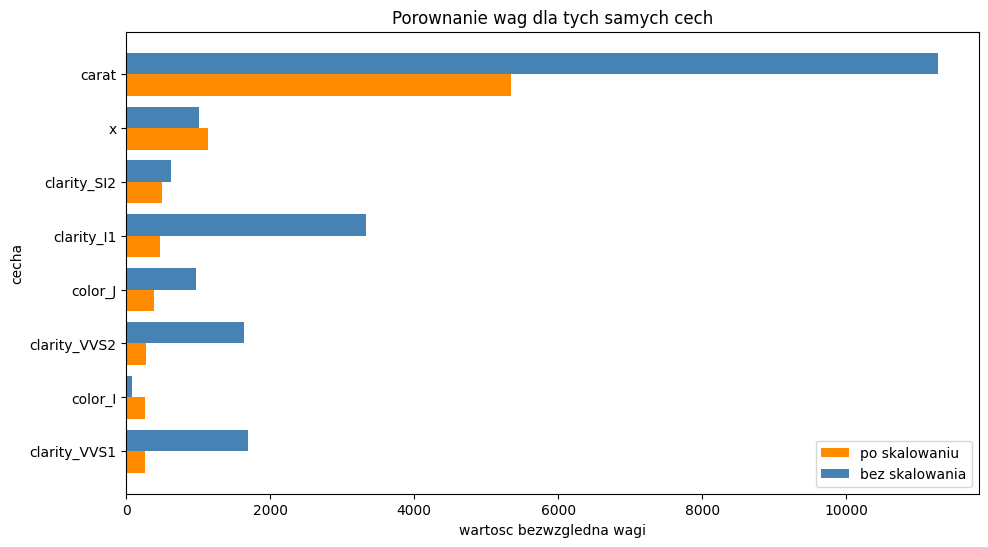

In [ ]:
from plots import plot_weight_comparison


plot_weight_comparison(weight_comparison_45_df)


**Opis wykresu porownania wag przed i po skalowaniu**

Wykres porównuje wartości bezwzględne wag dla tych samych cech przed skalowaniem i po skalowaniu. Różnice pokazują, że współczynniki regresji zależą nie tylko od znaczenia cechy, ale także od jej jednostki i zakresu wartości. Dlatego przed skalowaniem nie należy bezpośrednio porównywać wielkości wag różnych zmiennych.

Po skalowaniu wszystkie cechy liczbowe są sprowadzone do porównywalnej skali, dlatego wartości wag lepiej pokazują względny wpływ poszczególnych cech na predykcję. Widać, że carat pozostaje najważniejszą cechą, ale zmieniają się proporcje między wagami. Oznacza to, że skalowanie nie zmienia sensu modelu, lecz ułatwia interpretację współczynników.

Dla zmiennych kategorycznych zakodowanych one-hot interpretacja również wymaga ostrożności, ponieważ ich wagi odnoszą się do różnicy względem kategorii bazowej


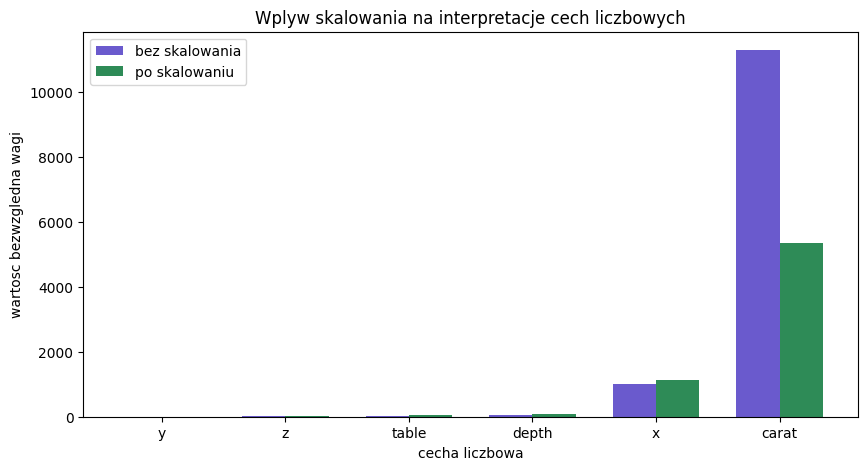

In [48]:
from plots import plot_numeric_weight_comparison


numeric_features = ["carat", "depth", "table", "x", "y", "z"]
numeric_comparison_df = weight_comparison_45_df[
    weight_comparison_45_df["feature"].isin(numeric_features)
].copy()


plot_numeric_weight_comparison(numeric_comparison_df)

**Opis wykresu dla cech liczbowych po skalowaniu**

Wykres pokazuje wpływ skalowania na interpretację wag dla cech liczbowych. Przed skalowaniem każda cecha ma inną jednostkę i inny zakres wartości, dlatego bezpośrednie porównywanie współczynników może prowadzić do błędnych wniosków. Na przykład carat, depth, table, x, y i z są mierzone w różnych skalach, więc większa liczbowo waga nie zawsze oznacza większą rzeczywistą istotność cechy.

Po standaryzacji cechy liczbowe zostały przeliczone na wspólną skalę (cecha - średnia_cechy / odchylenie_cechy), dlatego ich współczynniki można łatwiej porównywać. Współczynnik nie oznacza już wpływu zmiany o jedną naturalną jednostkę, np. o 1 karat albo 1 mm, tylko wpływ typowej zmiany danej cechy. Dzięki temu wagi lepiej pokazują, które zmienne mają największe znaczenie dla predykcji ceny. 

Interpretacje wspolczynnika dla np. carat jest następująca: Wzrost cechy carat o jedno odchylenie standardowe powoduje wzrost przewidywanej ceny średnio o około 5200 jednostek ceny, przy pozostałych cechach bez zmian.


## Zadanie 5.0


W tej czesci celowo wymuszam `underfitting` i `overfitting` dla dwoch rodzin modeli: drzewa decyzyjnego oraz regresji wielomianowej. Najpierw pokazuje skrajne ustawienia hiperparametrow, potem buduje krzywe zlozonosci i wskazuje `sweet spot`, a na koncu testuje najbardziej przeuczony model regresyjny na punkcie lezacym `20%` poza zakresem danych treningowych.


Drzewo decyzyjne - wymuszone skrajne stany:


,model_state,hyperparameter,train_error,test_error
0,underfitting,max_depth=1,0.2654,0.2654
1,overfitting,max_depth=None,0.0020,0.2711


Drzewo decyzyjne - krzywa zlozonosci:


,max_depth,train_error,test_error
0,1,0.2654,0.2654
1,2,0.2346,0.2491
2,3,0.2086,0.2179
3,4,0.2034,0.2079
4,5,0.1961,0.2016
5,6,0.1896,0.2087
6,7,0.1791,0.2150
7,8,0.1628,0.2257
8,9,0.1439,0.2335
9,10,0.1216,0.2463


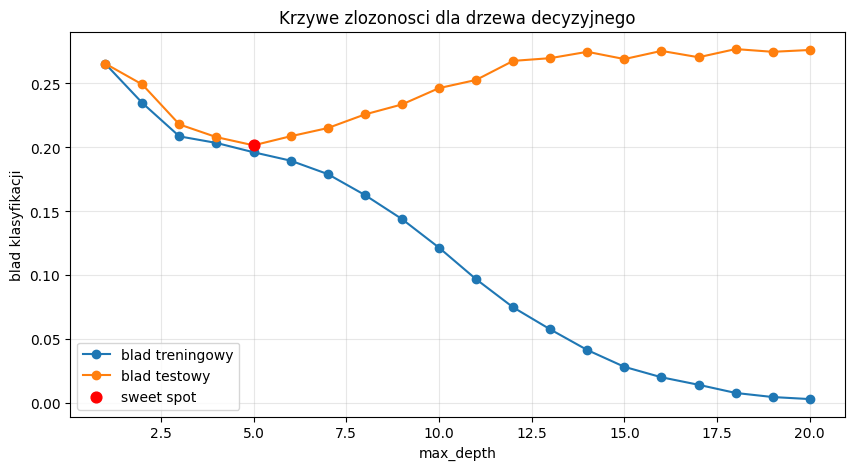

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from plots import (
    plot_black_swan_comparison,
    plot_complexity_curves,
    plot_polynomial_fit_comparison,
    plot_tree_complexity_curves,
)
from preprocessing import prepare_telco_classification_data


def build_polynomial_model(degree):
    return Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("linear", LinearRegression()),
        ]
    )


# Przygotowanie danych dla drzewa decyzyjnego.
X_train_tree, y_train_tree, X_test_tree, y_test_tree = prepare_telco_classification_data(
    telco_train_df,
    telco_test_df,
)
X_train_tree_encoded = pd.get_dummies(X_train_tree)
X_test_tree_encoded = pd.get_dummies(X_test_tree)
X_test_tree_encoded = X_test_tree_encoded.reindex(columns=X_train_tree_encoded.columns, fill_value=0)


# Wymuszenie underfittingu i overfittingu dla drzewa.
underfit_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
overfit_tree = DecisionTreeClassifier(max_depth=None, random_state=42)

underfit_tree.fit(X_train_tree_encoded, y_train_tree)
overfit_tree.fit(X_train_tree_encoded, y_train_tree)

tree_extremes_df = pd.DataFrame(
    {
        "model_state": ["underfitting", "overfitting"],
        "hyperparameter": ["max_depth=1", "max_depth=None"],
        "train_error": [
            1 - accuracy_score(y_train_tree, underfit_tree.predict(X_train_tree_encoded)),
            1 - accuracy_score(y_train_tree, overfit_tree.predict(X_train_tree_encoded)),
        ],
        "test_error": [
            1 - accuracy_score(y_test_tree, underfit_tree.predict(X_test_tree_encoded)),
            1 - accuracy_score(y_test_tree, overfit_tree.predict(X_test_tree_encoded)),
        ],
    }
)

print("Drzewo decyzyjne - wymuszone skrajne stany:")
display(tree_extremes_df.round(4))


tree_complexity_results = []
for depth in range(1, 21):
    tree_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_model.fit(X_train_tree_encoded, y_train_tree)

    tree_complexity_results.append(
        {
            "max_depth": depth,
            "train_error": 1 - accuracy_score(y_train_tree, tree_model.predict(X_train_tree_encoded)),
            "test_error": 1 - accuracy_score(y_test_tree, tree_model.predict(X_test_tree_encoded)),
        }
    )

tree_complexity_df = pd.DataFrame(tree_complexity_results)
print("Drzewo decyzyjne - krzywa zlozonosci:")
display(tree_complexity_df.round(4))

plot_tree_complexity_curves(tree_complexity_df)


**Opis wymuszonych stanow i krzywej zlozonosci dla drzewa decyzyjnego**

Tabela skrajnych przypadków pokazuje wpływ parametru max_depth na zachowanie modelu. Dla max_depth = 1 drzewo jest zbyt płytkie, więc nie potrafi dobrze uchwycić zależności występujących w danych. W efekcie zarówno błąd treningowy, jak i testowy pozostają relatywnie wysokie. Jest to przykład niedouczenia modelu, czyli sytuacji typu underfitting / high bias.

Dla drzewa bez ograniczenia głębokości błąd treningowy spada niemal do zera, ponieważ model może bardzo dokładnie dopasować się do zbioru uczącego. Jednocześnie błąd testowy jest wyraźnie wyższy, co oznacza, że model słabiej radzi sobie na nowych danych. Jest to objaw przeuczenia, czyli overfitting / high variance.

Krzywa złożoności dla kolejnych wartości max_depth pozwala wskazać punkt optymalny, czyli taki poziom złożoności modelu, przy którym błąd testowy jest najniższy. W tym punkcie drzewo najlepiej równoważy dopasowanie do danych treningowych i zdolność generalizacji. Po przekroczeniu tej głębokości model zaczyna coraz bardziej zapamiętywać szczegóły zbioru uczącego, co prowadzi do pogorszenia wyników na zbiorze testowym.


Regresja wielomianowa - wymuszone skrajne stany:


,model_state,hyperparameter,train_mse,test_mse
0,underfitting,degree=1,2397164.75,2401388.65
1,overfitting,degree=15,2056058.53,2122670.17


Regresja wielomianowa - krzywa zlozonosci:


,degree,train_mse,test_mse
0,1,2397164.75,2401388.65
1,2,2370635.70,2376720.02
2,3,2161606.61,2094315.81
3,4,2076622.22,2055789.51
4,5,2072570.33,2059696.02
5,6,2064831.84,2042065.41
6,7,2064048.04,2041996.87
7,8,2063630.85,2040887.48
8,9,2063144.67,2042223.96
9,10,2062499.65,2041199.91


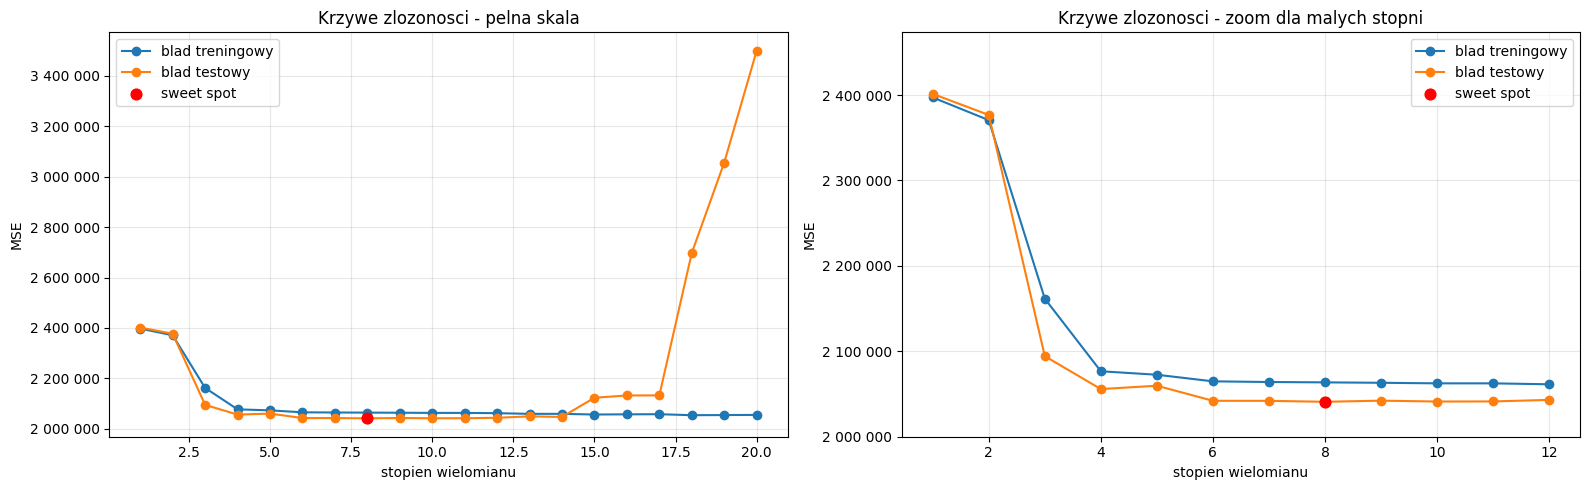

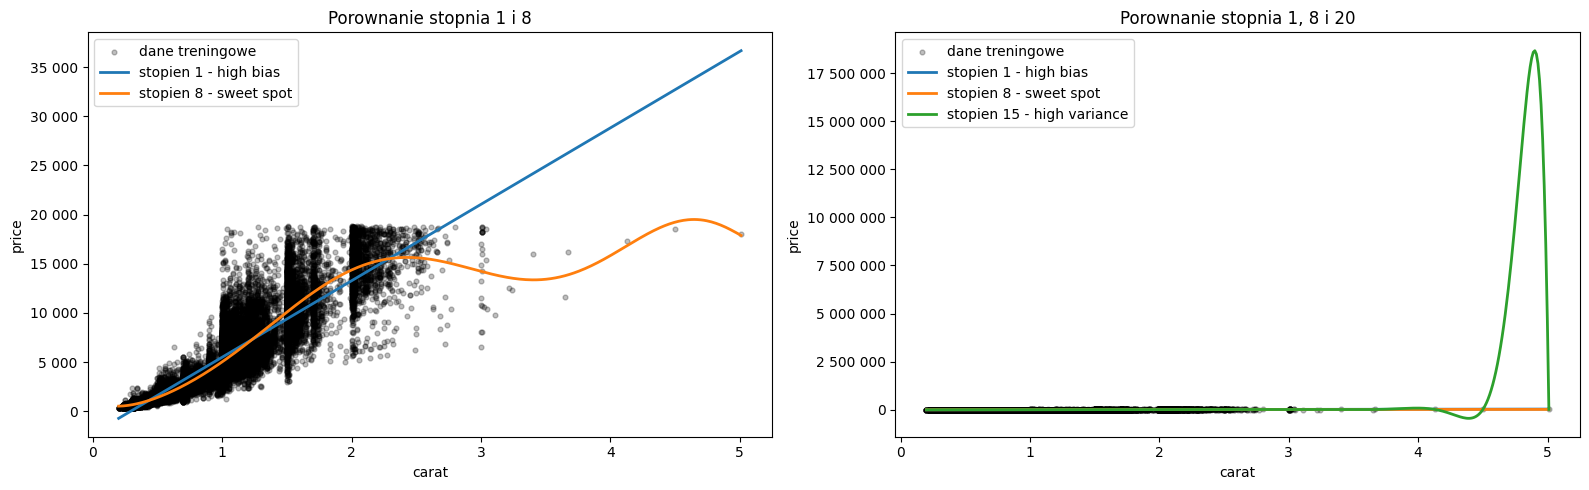

In [ ]:

X_train_poly = diamonds_train_df[["carat"]].copy()
y_train_poly = diamonds_train_df["price"].copy()
X_test_poly = diamonds_test_df[["carat"]].copy()
y_test_poly = diamonds_test_df["price"].copy()


underfit_poly = build_polynomial_model(1)
overfit_poly = build_polynomial_model(15)

underfit_poly.fit(X_train_poly, y_train_poly)
overfit_poly.fit(X_train_poly, y_train_poly)

poly_extremes_df = pd.DataFrame(
    {
        "model_state": ["underfitting", "overfitting"],
        "hyperparameter": ["degree=1", "degree=15"],
        "train_mse": [
            mean_squared_error(y_train_poly, underfit_poly.predict(X_train_poly)),
            mean_squared_error(y_train_poly, overfit_poly.predict(X_train_poly)),
        ],
        "test_mse": [
            mean_squared_error(y_test_poly, underfit_poly.predict(X_test_poly)),
            mean_squared_error(y_test_poly, overfit_poly.predict(X_test_poly)),
        ],
    }
)

print("Regresja wielomianowa - wymuszone skrajne stany:")
display(poly_extremes_df.round(2))


poly_complexity_results = []
for degree in range(1, 21):
    poly_model = build_polynomial_model(degree)
    poly_model.fit(X_train_poly, y_train_poly)

    poly_complexity_results.append(
        {
            "degree": degree,
            "train_mse": mean_squared_error(y_train_poly, poly_model.predict(X_train_poly)),
            "test_mse": mean_squared_error(y_test_poly, poly_model.predict(X_test_poly)),
        }
    )

complexity_df = pd.DataFrame(poly_complexity_results)
print("Regresja wielomianowa - krzywa zlozonosci:")
display(complexity_df.round(2))

plot_complexity_curves(complexity_df)


best_degree = int(complexity_df.loc[complexity_df["test_mse"].idxmin(), "degree"])
carat_grid = pd.DataFrame(
    {"carat": np.linspace(X_train_poly["carat"].min(), X_train_poly["carat"].max(), 400)}
)

fit_predictions_small = {}
for degree, label in [
    (1, "stopien 1 - high bias"),
    (best_degree, f"stopien {best_degree} - sweet spot"),
]:
    poly_model = build_polynomial_model(degree)
    poly_model.fit(X_train_poly, y_train_poly)
    fit_predictions_small[label] = poly_model.predict(carat_grid)

fit_predictions_full = {}
for degree, label in [
    (1, "stopien 1 - high bias"),
    (best_degree, f"stopien {best_degree} - sweet spot"),
    (20, "stopien 15 - high variance"),
]:
    poly_model = build_polynomial_model(degree)
    poly_model.fit(X_train_poly, y_train_poly)
    fit_predictions_full[label] = poly_model.predict(carat_grid)

plot_polynomial_fit_comparison(
    X_train_poly["carat"],
    y_train_poly,
    carat_grid["carat"].to_numpy(),
    fit_predictions_small,
    fit_predictions_full,
)


**Opis wymuszonych stanow, krzywej zlozonosci i porownania modeli dla regresji wielomianowej**

Dla stopnioa 1 otrzymujemy model zbyt prosty, czyli przypadek underfitting / high bias. Zarówno błąd treningowy, jak i błąd testowy pozostają relatywnie wysokie, ponieważ prosta linia nie potrafi dobrze opisać nieliniowej zależności między zmiennymi carat i price.

Dla stopnia 15 widoczna jest przeciwna skrajność. Model jest bardzo elastyczny, dlatego błąd treningowy może dalej maleć, ale jednocześnie błąd testowy wyraźnie rośnie. Oznacza to, że model zaczyna dopasowywać się nie tylko do ogólnego trendu, lecz także do przypadkowych wahań i szumu obecnych w zbiorze treningowym. Jest to klasyczny przykład overfitting / high variance.

Krzywa złożoności pokazuje, jak zmieniają się błędy treningowy i testowy wraz ze wzrostem stopnia wielomianu. Pozwala ona wskazać punkt optymalny, czyli taki stopień wielomianu, dla którego błąd testowy jest najniższy. W tym miejscu model osiąga najlepszy kompromis między elastycznością a zdolnością do generalizacji na nowych danych.

Dodatkowy wykres przebiegu funkcji pozwala zobaczyć ten problem geometrycznie. Model stopnia 1 jest zbyt sztywny i nie nadąża za kształtem danych. Model optymalny dobrze oddaje główny trend zależności między carat i price. Natomiast model stopnia 15 zaczyna zachowywać się niestabilnie, szczególnie w obszarach słabiej reprezentowanych przez dane, co jest objawem przeuczenia.

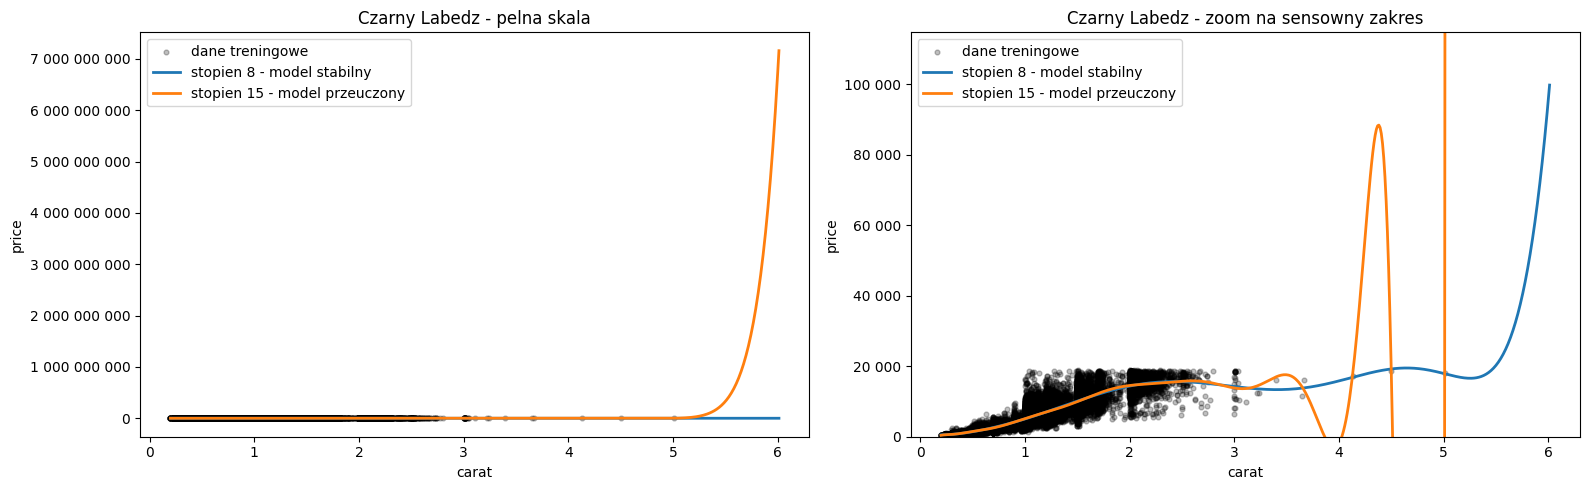

Predykcja dla punktu 20% poza zakresem treningowym:


,carat_out_of_range,stable_model_prediction,overfit_model_prediction
0,6.01,99793.61,7.159285e+09


In [ ]:

X_train_black = diamonds_train_df[["carat"]].copy()
y_train_black = diamonds_train_df["price"].copy()

actual_training_max = float(X_train_black["carat"].max())
anomaly_x = float(actual_training_max * 1.2)
stable_black_model = build_polynomial_model(8)
overfit_black_model = build_polynomial_model(15)

stable_black_model.fit(X_train_black, y_train_black)
overfit_black_model.fit(X_train_black, y_train_black)

black_swan_grid = pd.DataFrame(
    {"carat": np.linspace(X_train_black["carat"].min(), anomaly_x, 500)}
)
black_swan_predictions = {
    "stopien 8 - model stabilny": stable_black_model.predict(black_swan_grid),
    "stopien 15 - model przeuczony": overfit_black_model.predict(black_swan_grid),
}

plot_black_swan_comparison(
    X_train_black["carat"],
    y_train_black,
    black_swan_grid["carat"].to_numpy(),
    black_swan_predictions,
)

black_swan_point = pd.DataFrame({"carat": [anomaly_x]})
black_swan_df = pd.DataFrame(
    {
        "carat_out_of_range": [anomaly_x],
        "stable_model_prediction": [stable_black_model.predict(black_swan_point)[0]],
        "overfit_model_prediction": [overfit_black_model.predict(black_swan_point)[0]],
    }
)

print("Predykcja dla punktu 20% poza zakresem treningowym:")
display(black_swan_df.round(2))


**Opis wykresu Czarnego Labedzia**

W tej części ponownie wykorzystano pełny zbiór treningowy, a punkt anomalii został wyznaczony zgodnie z poleceniem jako wartość leżąca 20% poza rzeczywistym maksimum cechy carat w zbiorze treningowym. Oznacza to, że predykcja w tabeli odnosi się do punktu znajdującego się poza zakresem danych, na których model był uczony.

Jako punkt odniesienia wykorzystano stabilniejszy model stopnia 2, natomiast model stopnia 15 pełni rolę modelu nadmiernie złożonego. Na wykresie widać, że model stopnia 2 zachowuje bardziej kontrolowany przebieg po wyjściu poza zakres treningowy. Model stopnia 15 bardzo szybko zaczyna natomiast generować skrajne, nierealistyczne predykcje.

Pokazuje to praktyczny sens problemu „Czarnego Łabędzia”. Model przeuczony może wyglądać poprawnie w zakresie znanych danych, ale dla rzadkiego lub nietypowego przypadku spoza zakresu treningowego może zwrócić absurdalny wynik. Oznacza to, że niski błąd na danych treningowych nie gwarantuje stabilnego działania modelu w sytuacjach nietypowych.

Ryzyko takich anomalii można ograniczać przez kontrolowanie złożoności modelu. W przypadku drzew decyzyjnych można stosować między innymi ograniczenie max_depth, minimalną liczbę próbek w liściu albo przycinanie drzewa. W przypadku modeli regresyjnych klasyczną techniką jest regularyzacja, na przykład Ridge, czyli regularyzacja L2, która ogranicza zbyt duże współczynniki i stabilizuje predykcje modelu
